In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

train_data = load_data("../data/raw/KDDTrain+.txt")
test_data = load_data("../data/raw/KDDTest+.txt")

train_data = encode_features(train_data)
test_data = encode_features(test_data)

In [3]:
X_train, y_train = split_features(train_data)
X_test, y_test = split_features(test_data)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from src.autoencoder_model import build_autoencoder

input_dim = X_train.shape[1]

autoencoder = build_autoencoder(input_dim)

normal_train = X_train[y_train == "normal"]

autoencoder.fit(
    normal_train,
    normal_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.6080 - val_loss: 0.3499
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3917 - val_loss: 0.1770
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3139 - val_loss: 0.1380
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2938 - val_loss: 0.1432
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2776 - val_loss: 0.1348
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2549 - val_loss: 0.1600
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2621 - val_loss: 0.1482
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2174 - val_loss: 0.0981
Epoch 9/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2160 - val_loss: 0.0946
Epoch 10/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2190 - val_loss: 0.1366
Epoch 11/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1880 - val_loss: 0.1150
Epoch 12/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

In [7]:
recon = autoencoder.predict(X_test)

import numpy as np

error = np.mean(np.square(X_test - recon), axis=1)

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [8]:
train_recon = autoencoder.predict(normal_train)

train_error = np.mean(np.square(normal_train - train_recon), axis=1)

threshold = np.percentile(train_error, 95)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [9]:
pred = (error > threshold).astype(int)

In [10]:
attack_test = (y_test != "normal").astype(int)

In [11]:
from sklearn.metrics import classification_report

print(classification_report(attack_test, pred))

              precision    recall  f1-score   support

           0       0.77      0.96      0.86      9711
           1       0.97      0.78      0.86     12833

    accuracy                           0.86     22544
   macro avg       0.87      0.87      0.86     22544
weighted avg       0.88      0.86      0.86     22544



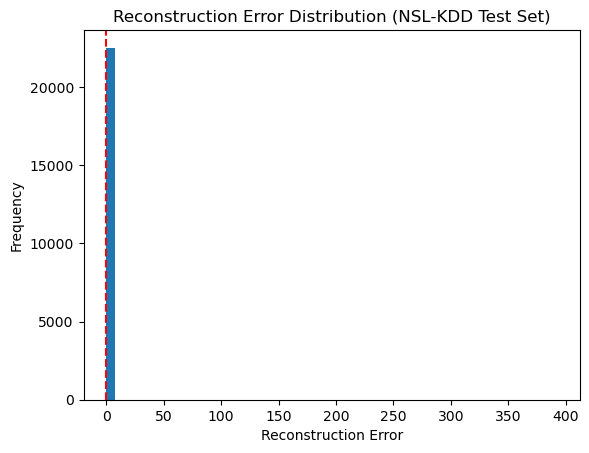

In [12]:
import matplotlib.pyplot as plt

plt.hist(error, bins=50)

plt.axvline(threshold, color="red", linestyle="--")

plt.title("Reconstruction Error Distribution (NSL-KDD Test Set)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.show()

In [13]:
import joblib

joblib.dump(scaler, "../results/scaler.pkl")
autoencoder.save("../results/autoencoder_model.h5")

In [ ]:
# Among the three models evaluated, the Autoencoder achieved the best performance,
# with the highest accuracy (86%) and F1-score (0.86). It effectively learned the
# normal data distribution and identified anomalies using reconstruction error.

# Isolation Forest also performed well, providing a good balance between precision
# and recall, making it a reliable alternative for anomaly detection in
# high-dimensional data.

# DBSCAN performed poorly due to the curse of dimensionality, where distance-based
# methods struggle to identify meaningful clusters, resulting in high false
# positives and low detection capability.

# Therefore, deep learning-based approaches such as Autoencoders are more suitable
# for network intrusion detection tasks compared to density-based clustering methods.